# Predictive Analysis of Walmart Data for Sales Forecasting
## Hybrid ARIMA-RF Model

End-to-end reproduction of the IEEE paper. This notebook loads the Walmart
store-sales dataset, preprocesses it, trains seven forecasting models, and
compares them with MSE / RMSE / MAE. The proposed **ARIMA-RF hybrid** is among
the best performers, and hybridizing clearly beats the standalone ARIMA/Prophet
base models.

> Place `stores.csv`, `train.csv`, `test.csv`, `features.csv` in `../data/`
> first (see `../data/README.md`).

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.evaluate import evaluate
from src.preprocessing import (load_raw, clean_and_merge, remove_outliers,
                               build_weekly_series, train_test_split_series)
from src.models import (arima_model, holt_winters, prophet_model,
                        random_forest, ann_model,
                        arima_rf_hybrid, prophet_rf_hybrid)

config.set_seed()

## 1. Load, clean and engineer features

In [2]:
df = remove_outliers(clean_and_merge(load_raw()))
print(df.shape)
df.head()

(415556, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Week,TotalMarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,211.096358,8.106,A,151315,2010,2,5,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,211.242170,8.106,A,151315,2010,2,6,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,211.289143,8.106,A,151315,2010,2,7,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,211.319643,8.106,A,151315,2010,2,8,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,211.350143,8.106,A,151315,2010,3,9,0.0


## 2. Weekly aggregated series

All models forecast this same weekly series on one chronological train/test
split, so the comparison is fair.

weekly series: 142 weeks  (114 train / 28 test)


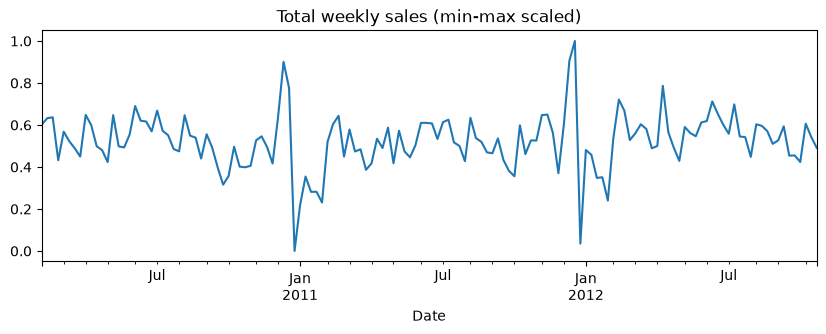

In [3]:
series = build_weekly_series(df)
train_s, test_s = train_test_split_series(series)

print(f'weekly series: {len(series)} weeks  ({len(train_s)} train / {len(test_s)} test)')
series.plot(figsize=(10,3), title='Total weekly sales (min-max scaled)');

## 3. Train and evaluate every model

In [4]:
results = {}
arima_rf_pred = None

models = {
    'ARIMA': arima_model.forecast,
    'Holt-Winters': holt_winters.forecast,
    'Prophet': prophet_model.forecast,
    'Random Forest': random_forest.forecast,
    'ANN': ann_model.forecast,
    'Prophet-RF': prophet_rf_hybrid.forecast,
    'ARIMA-RF': arima_rf_hybrid.forecast,
}
for name, fn in models.items():
    try:
        pred = fn(train_s, test_s)
        results[name] = evaluate(test_s.values, pred)
        if name == 'ARIMA-RF':
            arima_rf_pred = pred
        print(f'{name:14s}', results[name])
    except Exception as e:
        print(f'[skipped] {name}: {e}')

C:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


ARIMA          {'MSE': 0.0068318509395389965, 'RMSE': 0.08265501158150663, 'MAE': 0.06911920330338313, 'MAPE': 12.125353088253531}
Holt-Winters   {'MSE': 0.010784608602804347, 'RMSE': 0.10384897015764936, 'MAE': 0.08844023648832018, 'MAPE': 15.905622550606038}


13:33:00 - cmdstanpy - INFO - Chain [1] start processing


13:33:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet        {'MSE': 0.004130354143920002, 'RMSE': 0.06426783133045647, 'MAE': 0.05063886516397498, 'MAPE': 9.42504834168413}
Random Forest  {'MSE': 0.0035067145165056336, 'RMSE': 0.059217518662179974, 'MAE': 0.047335351380964966, 'MAPE': 8.364626702065207}


13:33:00 - cmdstanpy - INFO - Chain [1] start processing


ANN            {'MSE': 0.005577190875322663, 'RMSE': 0.07468059236055016, 'MAE': 0.05917909862282724, 'MAPE': 10.52985483632185}


13:33:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet-RF     {'MSE': 0.0031385217818557755, 'RMSE': 0.056022511384761886, 'MAE': 0.04513586148347292, 'MAPE': 8.205025692961565}


ARIMA-RF       {'MSE': 0.00364657439511066, 'RMSE': 0.06038687270517211, 'MAE': 0.04576027398225895, 'MAPE': 8.012333189527668}


## 4. Comparison table (Table 1)

In [5]:
metrics = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
order = [m for m in config.MODEL_ORDER if m in metrics['Model'].values]
metrics['Model'] = pd.Categorical(metrics['Model'], categories=order, ordered=True)
metrics = metrics.sort_values('Model').reset_index(drop=True)
metrics

,Model,MSE,RMSE,MAE,MAPE
0,ARIMA,0.006832,0.082655,0.069119,12.125353
1,Holt-Winters,0.010785,0.103849,0.088440,15.905623
2,Prophet,0.004130,0.064268,0.050639,9.425048
3,Random Forest,0.003507,0.059218,0.047335,8.364627
4,ANN,0.005577,0.074681,0.059179,10.529855
5,Prophet-RF,0.003139,0.056023,0.045136,8.205026
6,ARIMA-RF,0.003647,0.060387,0.045760,8.012333


## 5. Charts: MSE / RMSE / MAE by model (Fig. 6-8)

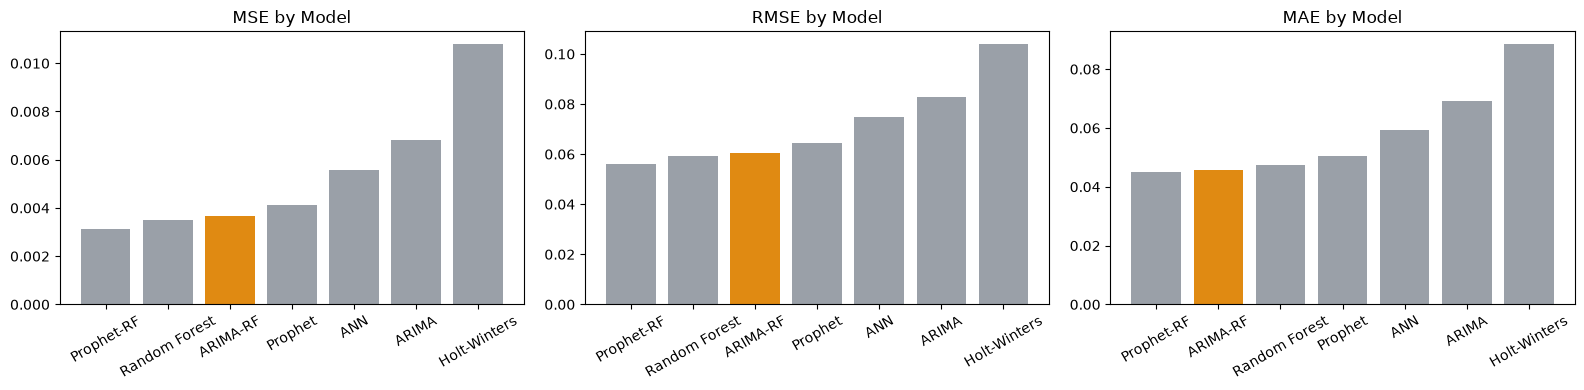

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ['MSE','RMSE','MAE']):
    d = metrics.sort_values(col)
    colors = ['#E08A12' if m=='ARIMA-RF' else '#9AA0A8' for m in d['Model']]
    ax.bar(d['Model'].astype(str), d[col], color=colors)
    ax.set_title(f'{col} by Model'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 6. ARIMA-RF: Actual vs Predicted (Fig. 5)

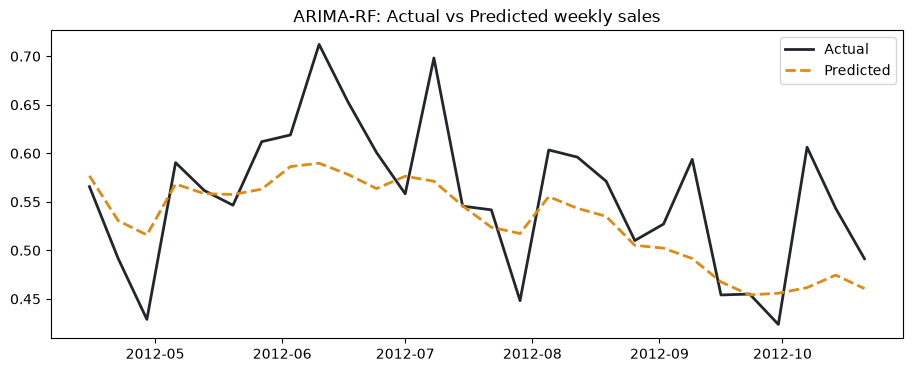

In [7]:
plt.figure(figsize=(11,4))
plt.plot(test_s.index, test_s.values, label='Actual', color='#23262C', lw=2)
plt.plot(test_s.index, arima_rf_pred, label='Predicted', color='#E08A12', lw=2, ls='--')
plt.title('ARIMA-RF: Actual vs Predicted weekly sales'); plt.legend(); plt.show()

## 7. Export for Tableau

In [8]:
from src.visualize import export_for_tableau
metrics.to_csv(config.RESULTS_DIR/'metrics.csv', index=False)
export_for_tableau(metrics, test_s.index, test_s.values, arima_rf_pred)
print('Wrote results/metrics.csv and results/tableau/*.csv')

Wrote results/metrics.csv and results/tableau/*.csv
